# Pantheon+SH0ES — Cosmological Inference with PyMultiNest

Parallel analysis to `pantheon_inference.ipynb` using **Nested Sampling** instead of MCMC.

**Key difference from emcee notebook**: the likelihood now uses the **full statistical covariance matrix**
(`Pantheon+SH0ES_STATONLY.cov`) following Eq. 9 of Brout et al. 2022:
$$-2\ln\mathcal{L} = \Delta\vec{D}^T\, C_{\rm stat}^{-1}\, \Delta\vec{D}$$
where $\Delta D_i = \mu_i - \mu_{\rm model}(z_i)$.

**M fixed**: $M = -19.253$ from Riess et al. 2022 / SH0ES Cepheid calibration (arXiv:2112.04510) -- Table 5 Baseline.
SNe Ia alone cannot constrain $H_0$ and $M$ simultaneously — they are perfectly degenerate.
$\delta_{\rm bias} = \delta_{\rm host} = 0$ (statistical-only analysis).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymultinest
import corner
import json
import os
from astropy.cosmology import FlatLambdaCDM, LambdaCDM, FlatwCDM, Flatw0waCDM
import astropy.units as u

os.makedirs('plots',  exist_ok=True)
os.makedirs('chains', exist_ok=True)

## 1. Load data and covariance matrix

In [5]:
# Path to save the best-fit parameters and covariance matrix
data = '/Users/edwinperez/Documents/Work/advanced_lab/topic2_pantheon_plus/data'

# Load SNe data
df   = pd.read_csv(f'{data}/Pantheon+SH0ES.dat', sep=r'\s+', comment='#')
mask = (df['zHD'] > 0.01) & (df['IS_CALIBRATOR'] == 0)
df   = df[mask].reset_index(drop=True)
N    = len(df)

z    = df['zHD'].values
mB   = df['mB'].values
x1   = df['x1'].values
c    = df['c'].values
print(f'SNe in fit: {N}   z range: {z.min():.4f}–{z.max():.4f}')

# Load STATONLY covariance matrix
# Format: first line = N, then N*N values read sequentially
with open(f'{data}/Pantheon+SH0ES_STATONLY.cov') as f:
    N_cov = int(f.readline())
    C_full = np.array(f.read().split(), dtype=float).reshape(N_cov, N_cov)

# Select only the rows/columns corresponding to our z>0.01 non-calibrator cut
# The .cov rows correspond to the same ordering as the .dat file
orig_mask = (pd.read_csv(f'{data}/Pantheon+SH0ES.dat', sep=r'\s+', comment='#')
             .pipe(lambda d: (d['zHD'] > 0.01) & (d['IS_CALIBRATOR'] == 0)).values)
idx  = np.where(orig_mask)[0]
C    = C_full[np.ix_(idx, idx)]   # (N, N) submatrix
C_inv = np.linalg.inv(C)
print(f'Covariance matrix loaded and inverted: {C.shape}')

# Fixed M from SH0ES Cepheid calibration — Riess et al. 2022 (arXiv:2112.04510) -- Table 5 Baseline
M_fixed = -19.253

SNe in fit: 1580   z range: 0.0102–2.2614
Covariance matrix loaded and inverted: (1580, 1580)


## 2. Model and likelihood

Observed distance modulus (Tripp estimator, Eq. 1, $\delta$s = 0):
$$\mu_{\rm obs} = m_B + \alpha x_1 - \beta c - M$$

Likelihood with full covariance (Eq. 9 of Brout+2022):
$$\ln\mathcal{L} = -\frac{1}{2}\left[\Delta\vec{D}^T C^{-1} \Delta\vec{D} + \ln\det(2\pi C)\right]$$

Note: $\ln\det(2\pi C)$ is constant w.r.t. parameters — included for completeness but does not affect the posterior shape.

In [6]:
# Log-det term (constant — computed once)
sign, logdet = np.linalg.slogdet(2 * np.pi * C)

def mu_obs(alpha, beta):
    """Tripp estimator with M fixed."""
    return mB + alpha * x1 - beta * c - M_fixed

def log_likelihood_cov(mu_th, alpha, beta):
    """Likelihood using full covariance matrix (Eq. 9)."""
    delta = mu_obs(alpha, beta) - mu_th
    chi2  = delta @ C_inv @ delta
    return -0.5 * (chi2 + logdet)

def mu_theory(z_arr, name, theta_cosmo):
    """Theoretical distance modulus for each cosmological model."""
    H0, Om0 = theta_cosmo[0], theta_cosmo[1]
    if name == 'Flat LCDM':
        cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    elif name == 'Curved LCDM':
        cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=1-Om0-theta_cosmo[2])
    elif name == 'Flat wCDM':
        cosmo = FlatwCDM(H0=H0, Om0=Om0, w0=theta_cosmo[2])
    elif name == 'Flat w0waCDM':
        cosmo = Flatw0waCDM(H0=H0, Om0=Om0, w0=theta_cosmo[2], wa=theta_cosmo[3])
    return 5*np.log10(cosmo.luminosity_distance(z_arr).to(u.Mpc).value) + 25

## 3. PyMultiNest runner

MultiNest requires two functions:
- `prior(cube, ndim, nparams)`: maps unit hypercube [0,1]^n → physical parameter space
- `loglike(cube, ndim, nparams)`: evaluates log-likelihood at that point

In [7]:
def run_multinest(model_name, prior_fn, loglike_fn, param_names,
                  n_live=400, output_dir='chains/mn_'):
    """
    Run PyMultiNest for a given model.
    prior_fn  : maps cube[i] in [0,1] to physical parameter i (in-place)
    loglike_fn: returns log-likelihood given cube
    n_live    : number of live points (more = more accurate evidence, slower)
    """
    ndim   = len(param_names)
    prefix = output_dir + model_name.replace(' ', '_') + '_'
    os.makedirs(os.path.dirname(prefix), exist_ok=True)

    pymultinest.run(
        loglike_fn, prior_fn, ndim,
        outputfiles_basename = prefix,
        n_live_points        = n_live,
        evidence_tolerance   = 0.5,    # stop when dlog(Z) < 0.5
        sampling_efficiency  = 0.8,    # 0.8 for parameter estimation
        multimodal           = False,
        verbose              = True,
    )

    # Load results
    result = pymultinest.Analyzer(ndim, outputfiles_basename=prefix)
    stats  = result.get_stats()
    data   = result.get_equal_weighted_posterior()[:, :-1]  # drop last weight col

    # Save for comparison notebook
    np.save(f'chains/mn_{model_name.replace(" ","_")}.npy', data)
    with open(f'chains/mn_{model_name.replace(" ","_")}_stats.json', 'w') as f:
        json.dump(stats, f, indent=2)

    print(f'\nlog Z (evidence) = {stats["global evidence"]:.3f} ± {stats["global evidence error"]:.3f}')
    return data, stats

def print_results(data, param_names):
    print(f'  {"Param":>10}  {"16%":>9}  {"Median":>9}  {"84%":>9}  {"-σ":>7}  {"+σ":>7}')
    print('  ' + '-'*58)
    for i, name in enumerate(param_names):
        p16, p50, p84 = np.percentile(data[:,i], [16, 50, 84])
        print(f'  {name:>10}  {p16:>9.4f}  {p50:>9.4f}  {p84:>9.4f}  {p50-p16:>7.4f}  {p84-p50:>7.4f}')

def save_corner(data, param_names, title, fname):
    fig = corner.corner(data, labels=param_names,
                        quantiles=[0.16, 0.5, 0.84],
                        show_titles=True, title_fmt='.3f',
                        plot_datapoints=False, smooth=1.0)
    fig.suptitle(title, y=1.01, fontsize=13)
    fig.savefig(f'plots/{fname}', dpi=120, bbox_inches='tight')
    plt.show()

## 4. Model 1 — Flat ΛCDM
Parameters: $(H_0,\, \Omega_m,\, \alpha,\, \beta)$

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    4
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.982533
Replacements:                                450
Total Samples:                               458
Nested Sampling ln(Z):             -28289.966044
Importance Nested Sampling ln(Z):     504.474717 +/-  0.998904
Acceptance Rate:                        0.972763
Replacements:                                500
Total Samples:                               514
Nested Sampling ln(Z):             -22562.694024
Importance Nested Sampling ln(Z):     504.359363 +/-  0.999023
Acceptance Rate:                        0.932203
Replacements:                                550


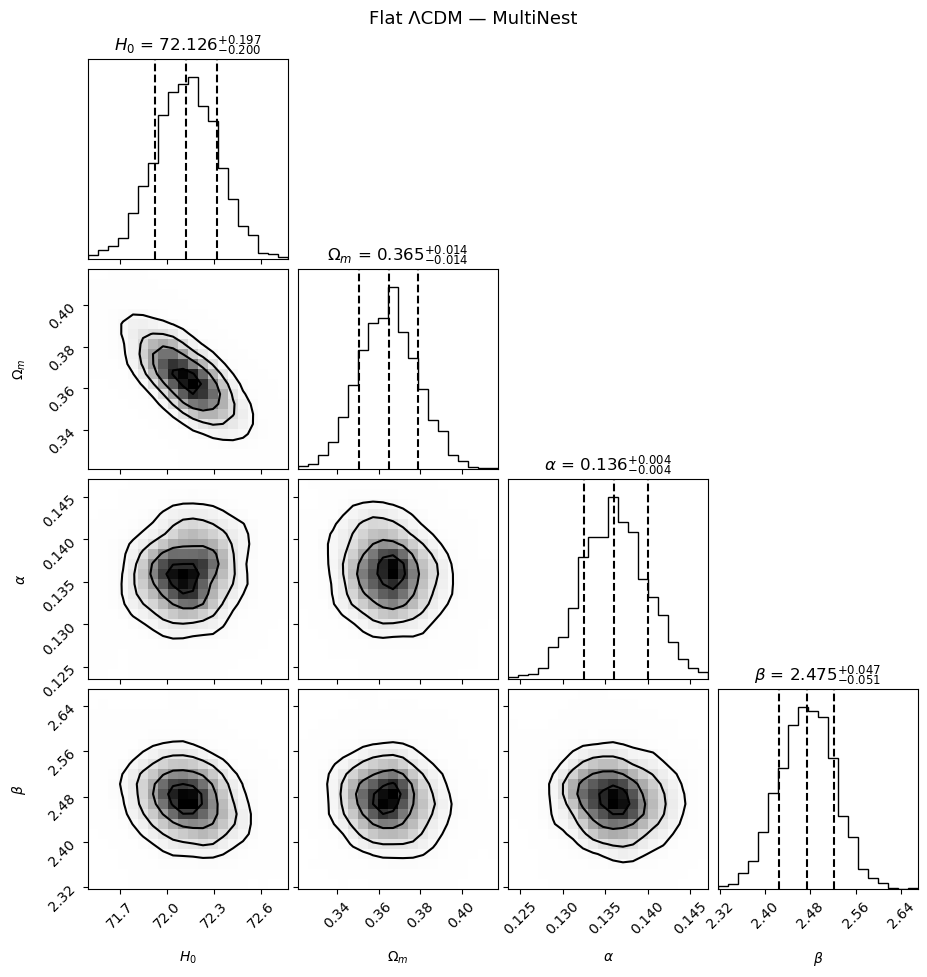

In [8]:
# Prior ranges — same as emcee notebook for direct comparison
PRIOR_FLCDM = [(50, 100), (0.05, 0.7), (0.0, 1.0), (1.0, 5.0)]
NAMES_FLCDM = [r'$H_0$', r'$\Omega_m$', r'$\alpha$', r'$\beta$']

def prior_flcdm(cube, ndim, nparams):
    """Uniform prior: maps [0,1] -> [lo, hi] for each parameter."""
    for i, (lo, hi) in enumerate(PRIOR_FLCDM):
        cube[i] = lo + (hi - lo) * cube[i]

def loglike_flcdm(cube, ndim, nparams):
    H0, Om0, alpha, beta = cube[0], cube[1], cube[2], cube[3]
    mu_th = mu_theory(z, 'Flat LCDM', [H0, Om0])
    if not np.all(np.isfinite(mu_th)): return -1e30
    return log_likelihood_cov(mu_th, alpha, beta)

data_flcdm, stats_flcdm = run_multinest('Flat LCDM', prior_flcdm, loglike_flcdm, NAMES_FLCDM)
print_results(data_flcdm, NAMES_FLCDM)
save_corner(data_flcdm, NAMES_FLCDM, 'Flat ΛCDM — MultiNest', 'mn_corner_flcdm.png')

## 5. Model 2 — Curved ΛCDM
Parameters: $(H_0,\, \Omega_m,\, \Omega_k,\, \alpha,\, \beta)$

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    5
 *****************************************************
 Starting MultiNest
 generating live points


/Users/edwinperez/miniconda3/envs/advanced_lab_multinest/lib/python3.14/site-packages/astropy/cosmology/_src/flrw/base.py:968: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/Users/edwinperez/miniconda3/envs/advanced_lab_multinest/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = ufunc(*args, out=...)
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_86698/3523360964.py:25: RuntimeWarning: invalid value encountered in log10
  return 5*np.log10(cosmo.luminosity_distance(z_arr).to(u.Mpc).value) + 25


 live points generated, starting sampling
Acceptance Rate:                        0.984683
Replacements:                                450
Total Samples:                               457
Nested Sampling ln(Z):             -32090.757884
Importance Nested Sampling ln(Z):     535.698104 +/-  0.998905
Acceptance Rate:                        0.961538
Replacements:                                500
Total Samples:                               520
Nested Sampling ln(Z):             -25982.242290
Importance Nested Sampling ln(Z):     598.872009 +/-  0.999038
Acceptance Rate:                        0.943396
Replacements:                                550
Total Samples:                               583
Nested Sampling ln(Z):             -21993.936164
Importance Nested Sampling ln(Z):     598.757651 +/-  0.999142
Acceptance Rate:                        0.914634
Replacements:                                600
Total Samples:                               656
Nested Sampling ln(Z):            

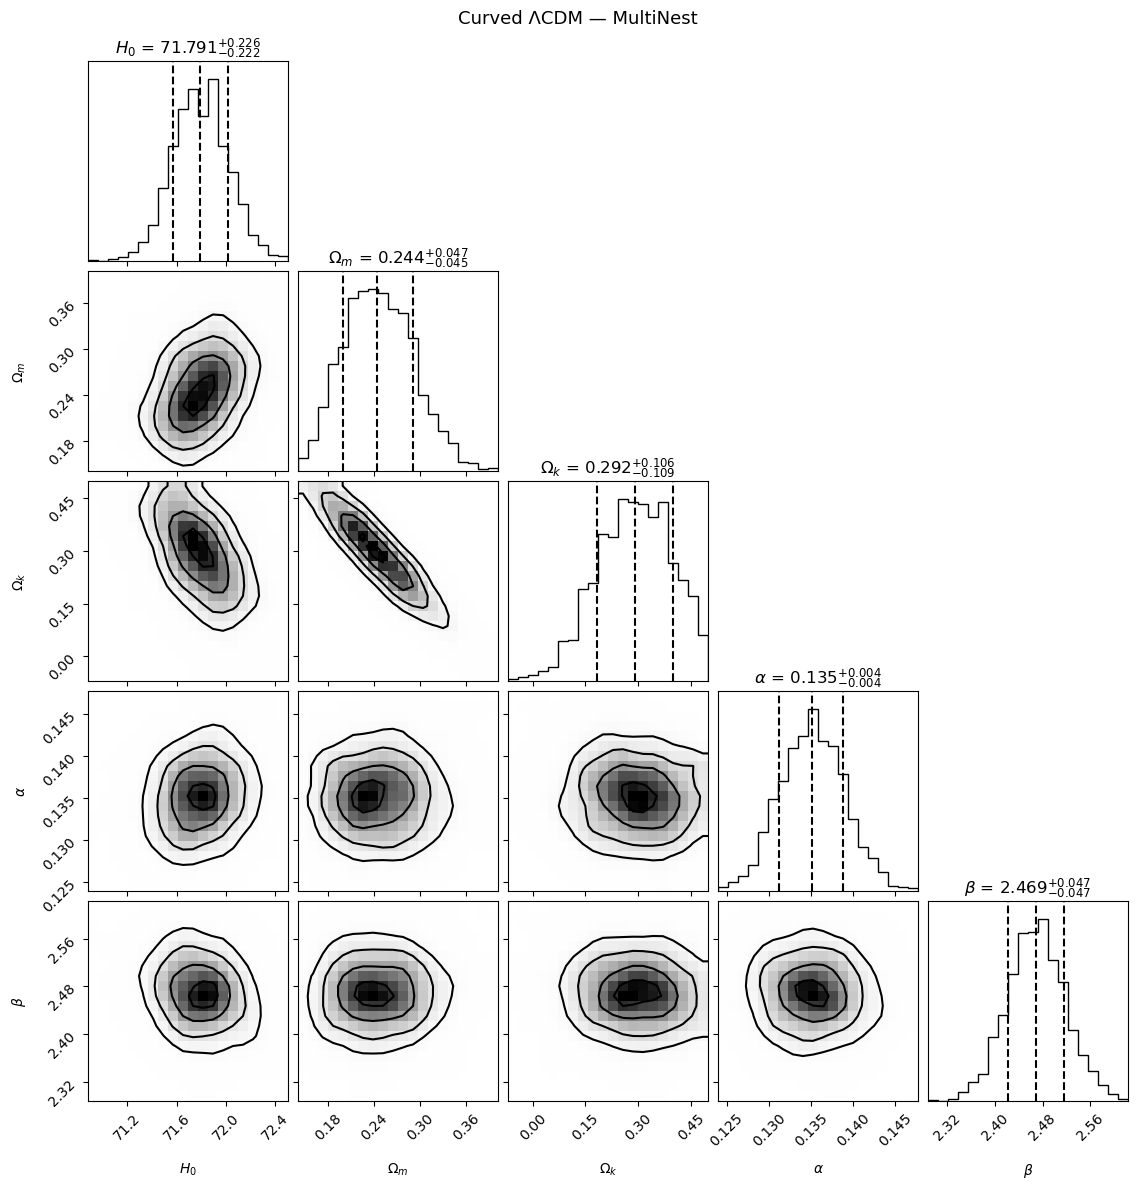

In [9]:
PRIOR_LCDM = [(50,100), (0.05,0.7), (-0.5,0.5), (0.0,1.0), (1.0,5.0)]
NAMES_LCDM = [r'$H_0$', r'$\Omega_m$', r'$\Omega_k$', r'$\alpha$', r'$\beta$']

def prior_lcdm(cube, ndim, nparams):
    for i, (lo, hi) in enumerate(PRIOR_LCDM):
        cube[i] = lo + (hi - lo) * cube[i]

def loglike_lcdm(cube, ndim, nparams):
    H0, Om0, Ok0, alpha, beta = cube[0], cube[1], cube[2], cube[3], cube[4]
    Ode0 = 1.0 - Om0 - Ok0
    if Ode0 < 0: return -1e30
    mu_th = mu_theory(z, 'Curved LCDM', [H0, Om0, Ok0])
    if not np.all(np.isfinite(mu_th)): return -1e30
    return log_likelihood_cov(mu_th, alpha, beta)

data_lcdm, stats_lcdm = run_multinest('Curved LCDM', prior_lcdm, loglike_lcdm, NAMES_LCDM)
print_results(data_lcdm, NAMES_LCDM)
save_corner(data_lcdm, NAMES_LCDM, 'Curved ΛCDM — MultiNest', 'mn_corner_lcdm.png')

## 6. Model 3 — Flat wCDM
Parameters: $(H_0,\, \Omega_m,\, w,\, \alpha,\, \beta)$

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    5
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.993377
Replacements:                                450
Total Samples:                               453
Nested Sampling ln(Z):             -29899.107745
Importance Nested Sampling ln(Z):     190.935693 +/-  0.998896
Acceptance Rate:                        0.972763
Replacements:                                500
Total Samples:                               514
Nested Sampling ln(Z):             -23279.978190
Importance Nested Sampling ln(Z):     190.809362 +/-  0.999027
Acceptance Rate:                        0.938567
Replacements:                                550


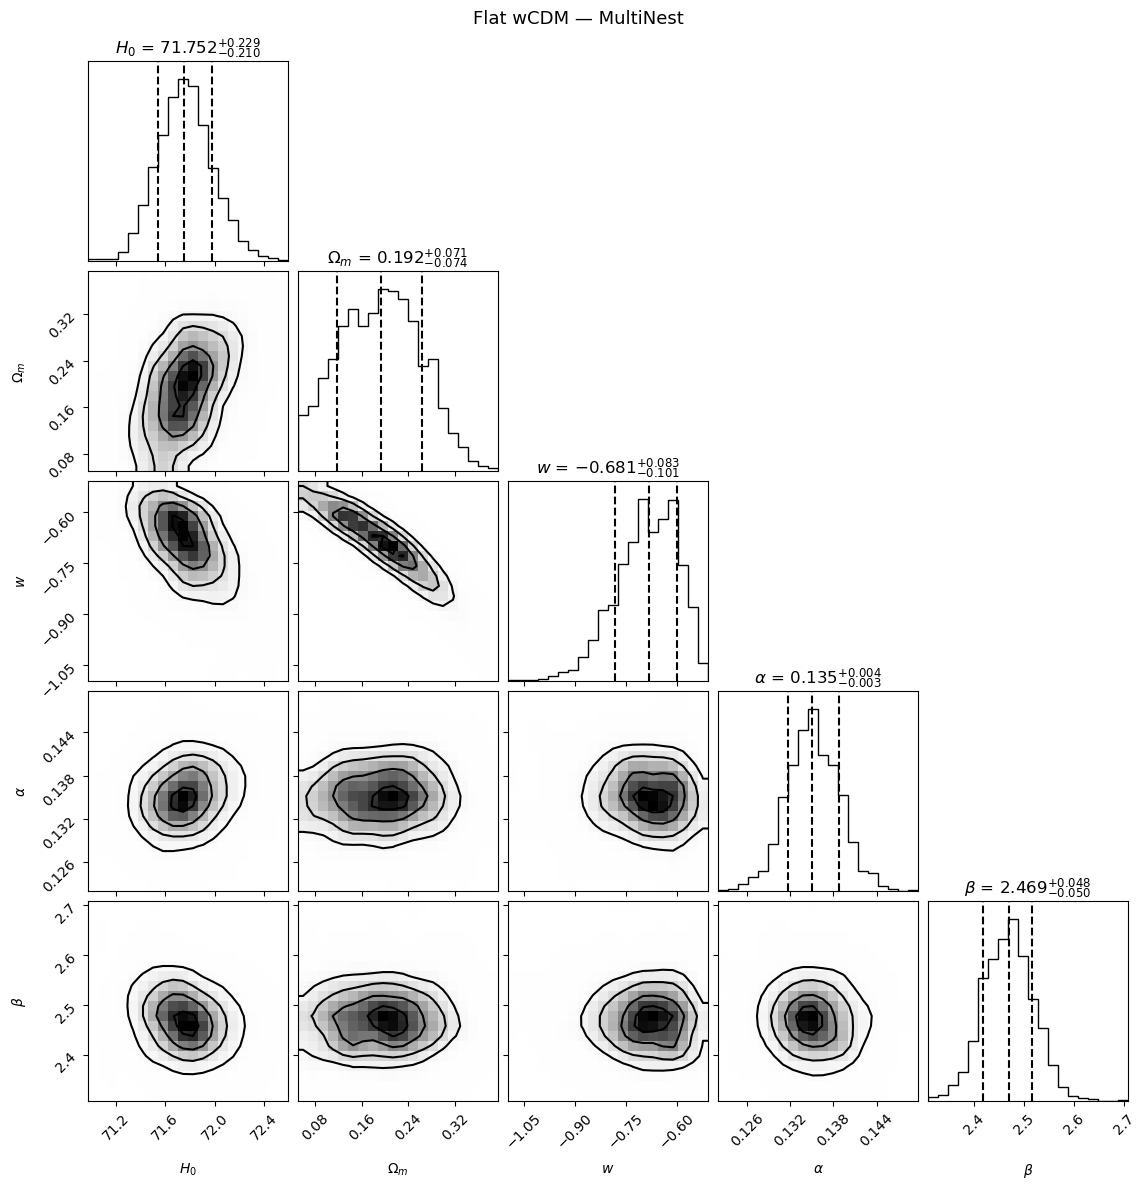

In [10]:
PRIOR_WCDM = [(50,100), (0.05,0.7), (-3.0,0.0), (0.0,1.0), (1.0,5.0)]
NAMES_WCDM = [r'$H_0$', r'$\Omega_m$', r'$w$', r'$\alpha$', r'$\beta$']

def prior_wcdm(cube, ndim, nparams):
    for i, (lo, hi) in enumerate(PRIOR_WCDM):
        cube[i] = lo + (hi - lo) * cube[i]

def loglike_wcdm(cube, ndim, nparams):
    H0, Om0, w, alpha, beta = cube[0], cube[1], cube[2], cube[3], cube[4]
    mu_th = mu_theory(z, 'Flat wCDM', [H0, Om0, w])
    if not np.all(np.isfinite(mu_th)): return -1e30
    return log_likelihood_cov(mu_th, alpha, beta)

data_wcdm, stats_wcdm = run_multinest('Flat wCDM', prior_wcdm, loglike_wcdm, NAMES_WCDM)
print_results(data_wcdm, NAMES_WCDM)
save_corner(data_wcdm, NAMES_WCDM, 'Flat wCDM — MultiNest', 'mn_corner_wcdm.png')

## 7. Model 4 — Flat w0waCDM *(extra)*
Parameters: $(H_0,\, \Omega_m,\, w_0,\, w_a,\, \alpha,\, \beta)$

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    6
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.993377
Replacements:                                450
Total Samples:                               453
Nested Sampling ln(Z):             -30627.626488
Importance Nested Sampling ln(Z):     519.318080 +/-  0.998896
Acceptance Rate:                        0.967118
Replacements:                                500
Total Samples:                               517
Nested Sampling ln(Z):             -26372.739743
Importance Nested Sampling ln(Z):     519.185929 +/-  0.999032
Acceptance Rate:                        0.941781
Replacements:                                550


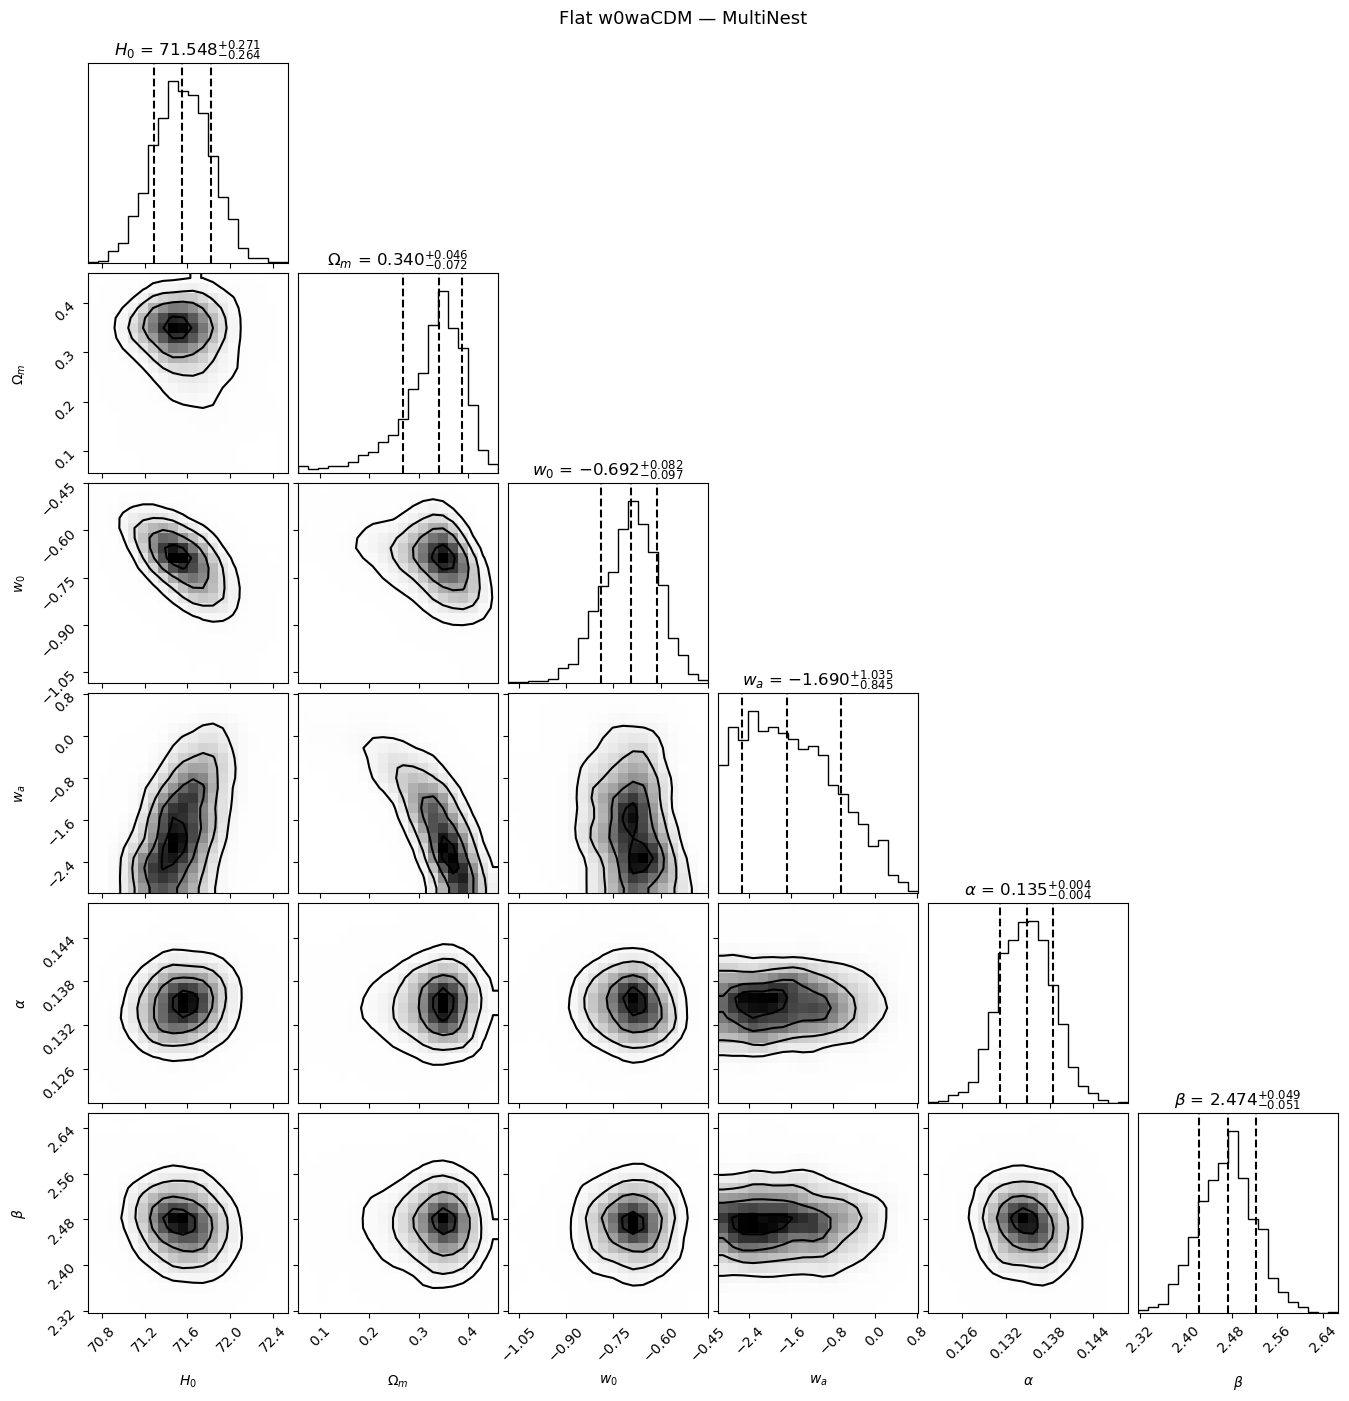

In [11]:
PRIOR_W0WA = [(50,100), (0.05,0.7), (-3.0,0.0), (-3.0,3.0), (0.0,1.0), (1.0,5.0)]
NAMES_W0WA = [r'$H_0$', r'$\Omega_m$', r'$w_0$', r'$w_a$', r'$\alpha$', r'$\beta$']

def prior_w0wa(cube, ndim, nparams):
    for i, (lo, hi) in enumerate(PRIOR_W0WA):
        cube[i] = lo + (hi - lo) * cube[i]

def loglike_w0wa(cube, ndim, nparams):
    H0, Om0, w0, wa, alpha, beta = cube[0],cube[1],cube[2],cube[3],cube[4],cube[5]
    mu_th = mu_theory(z, 'Flat w0waCDM', [H0, Om0, w0, wa])
    if not np.all(np.isfinite(mu_th)): return -1e30
    return log_likelihood_cov(mu_th, alpha, beta)

data_w0wa, stats_w0wa = run_multinest('Flat w0waCDM', prior_w0wa, loglike_w0wa, NAMES_W0WA)
print_results(data_w0wa, NAMES_W0WA)
save_corner(data_w0wa, NAMES_W0WA, 'Flat w0waCDM — MultiNest', 'mn_corner_w0wa.png')

## 8. Save evidence values for model comparison

In [12]:
# Collect log-evidence (log Z) from MultiNest — needed for Bayes factor comparison
evidence = {
    'Flat LCDM'   : stats_flcdm['global evidence'],
    'Curved LCDM' : stats_lcdm['global evidence'],
    'Flat wCDM'   : stats_wcdm['global evidence'],
    'Flat w0waCDM': stats_w0wa['global evidence'],
}
with open('chains/mn_evidence.json', 'w') as f:
    json.dump(evidence, f, indent=2)

print('log Z per model (relative to Flat ΛCDM):')
ref = evidence['Flat LCDM']
for name, logZ in evidence.items():
    print(f'  {name:15s}: log Z = {logZ:.2f}   Δlog Z = {logZ-ref:+.2f}')

log Z per model (relative to Flat ΛCDM):
  Flat LCDM      : log Z = 742.19   Δlog Z = +0.00
  Curved LCDM    : log Z = 744.37   Δlog Z = +2.18
  Flat wCDM      : log Z = 744.00   Δlog Z = +1.80
  Flat w0waCDM   : log Z = 744.33   Δlog Z = +2.13
